In [2]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# 1. Initialize Data
students = ['A', 'B', 'C', 'D', 'E']
maths = np.array([2, 4, 6, 8, 10])
science = np.array([1, 3, 5, 7, 9])
X = np.stack((maths, science), axis=1)

print("--- STEP 1: MANUAL PCA MATRIX CALCULATIONS ---")
# Centering
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

# Covariance Matrix (ddof=0 for population standard common in classrooms)
cov_matrix = np.cov(X_centered, rowvar=False, ddof=0)
print(f"Covariance Matrix:\n{cov_matrix}\n")

# Eigenvalues & Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# Sort descending
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"Eigenvalues (Variance explained): {eigenvalues}")
print(f"Principal Component 1 Loading Vector: {eigenvectors[:, 0]}")

# Transform data to PC space
manual_PC_scores = np.dot(X_centered, eigenvectors)
print(f"Calculated PC1 Scores for A-E: {manual_PC_scores[:, 0]}\n")


print("--- STEP 2: VERIFICATION WITH SCIKIT-LEARN PCA ---")
pca = PCA(n_components=1)
sklearn_PC1 = pca.fit_transform(X)
print(f"Sklearn PC1 Scores:\n{sklearn_PC1.flatten()}\n")


print("--- STEP 3: SIMPLE LINEAR REGRESSION (Predict Science using Maths) ---")
# Manual SLR
m = cov_matrix[0, 1] / cov_matrix[0, 0]
c = X_mean[1] - m * X_mean[0]
print(f"Manual SLR Equation: Science = {m:.1f} * Maths + ({c:.1f})")

# Sklearn SLR
slr_model = LinearRegression()
slr_model.fit(maths.reshape(-1, 1), science)
print(f"Sklearn SLR Formula: Science = {slr_model.coef_[0]:.1f} * Maths + ({slr_model.intercept_:.1f})")



--- STEP 1: MANUAL PCA MATRIX CALCULATIONS ---
Covariance Matrix:
[[8. 8.]
 [8. 8.]]

Eigenvalues (Variance explained): [16.  0.]
Principal Component 1 Loading Vector: [0.70710678 0.70710678]
Calculated PC1 Scores for A-E: [-5.65685425 -2.82842712  0.          2.82842712  5.65685425]

--- STEP 2: VERIFICATION WITH SCIKIT-LEARN PCA ---
Sklearn PC1 Scores:
[-5.65685425 -2.82842712  0.          2.82842712  5.65685425]

--- STEP 3: SIMPLE LINEAR REGRESSION (Predict Science using Maths) ---
Manual SLR Equation: Science = 1.0 * Maths + (-1.0)
Sklearn SLR Formula: Science = 1.0 * Maths + (-1.0)


PC1 Variance Captured: 99.29%
SLR Formula: Science = 1.329 * Study_Hours + 0.425
MLR Formula: Science = 11.58 + (-0.74 * Study_Hours) + (1.24 * PC1)


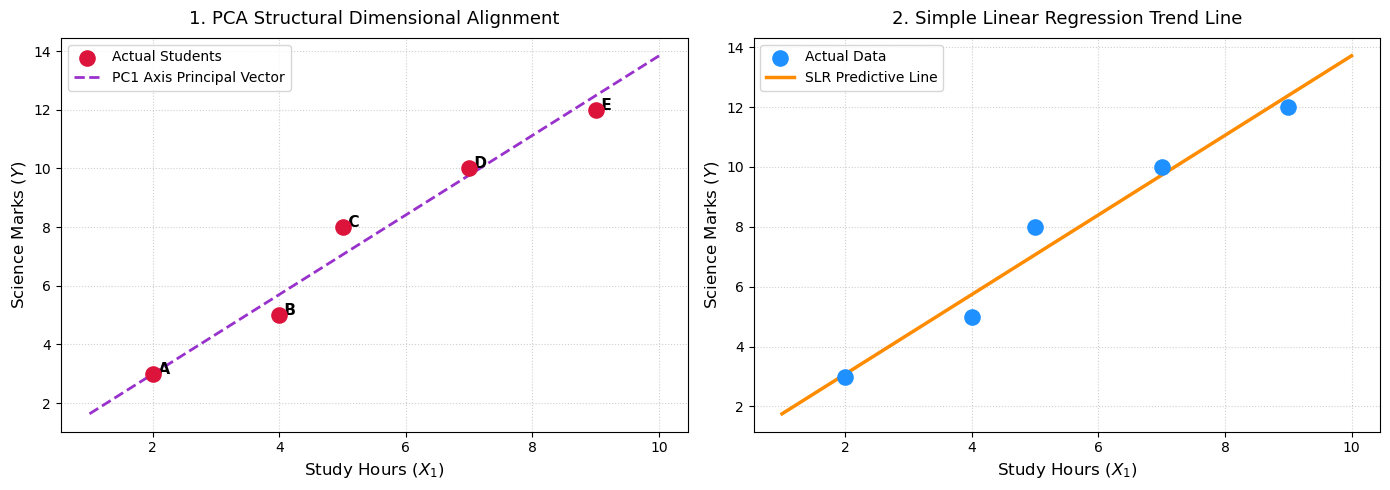

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
students = ['A', 'B', 'C', 'D', 'E']
X1 = np.array([2, 4, 5, 7, 9])      
science = np.array([3, 5, 8, 10, 12])
X_2d = np.stack((X1, science), axis=1)
mean_vals = np.mean(X_2d, axis=0)
X_centered = X_2d - mean_vals
cov_matrix = np.cov(X_centered, rowvar=False, ddof=0)
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
idx = eig_vals.argsort()[::-1]
eig_vals, eig_vecs = eig_vals[idx], eig_vecs[:, idx]
pc1_scores = np.dot(X_centered, eig_vecs[:, 0])

m_slr = cov_matrix[0, 1] / cov_matrix[0, 0]
c_slr = mean_vals[1] - (m_slr * mean_vals[0])
X_design = np.stack((np.ones(len(X1)), X1, pc1_scores), axis=1)
beta_mlr = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ science

print(f"PC1 Variance Captured: {(eig_vals[0]/sum(eig_vals))*100:.2f}%")
print(f"SLR Formula: Science = {m_slr:.3f} * Study_Hours + {c_slr:.3f}")
print(f"MLR Formula: Science = {beta_mlr[0]:.2f} + ({beta_mlr[1]:.2f} * Study_Hours) + ({beta_mlr[2]:.2f} * PC1)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.scatter(X1, science, color='crimson', s=120, zorder=5, label='Actual Students')
for i, txt in enumerate(students):
    ax1.annotate(f" {txt}", (X1[i], science[i]), fontsize=11, fontweight='bold')

x_range = np.linspace(1, 10, 100)
pc1_slope = eig_vecs[1, 0] / eig_vecs[0, 0]
y_pc1_line = mean_vals[1] + pc1_slope * (x_range - mean_vals[0])
ax1.plot(x_range, y_pc1_line, '--', color='darkorchid', linewidth=2, label='PC1 Axis Principal Vector')

ax1.set_xlabel('Study Hours ($X_1$)', fontsize=12)
ax1.set_ylabel('Science Marks ($Y$)', fontsize=12)
ax1.set_title('1. PCA Structural Dimensional Alignment', fontsize=13, pad=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

ax2.scatter(X1, science, color='dodgerblue', s=120, zorder=5, label='Actual Data')
y_pred_slr = m_slr * x_range + c_slr
ax2.plot(x_range, y_pred_slr, color='darkorange', linewidth=2.5, label='SLR Predictive Line')

ax2.set_xlabel('Study Hours ($X_1$)', fontsize=12)
ax2.set_ylabel('Science Marks ($Y$)', fontsize=12)
ax2.set_title('2. Simple Linear Regression Trend Line', fontsize=13, pad=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()


Regression Equation: Marks = 0.9 * Hours + (-0.6)
Predicted marks for 6 hours of study: 4.8


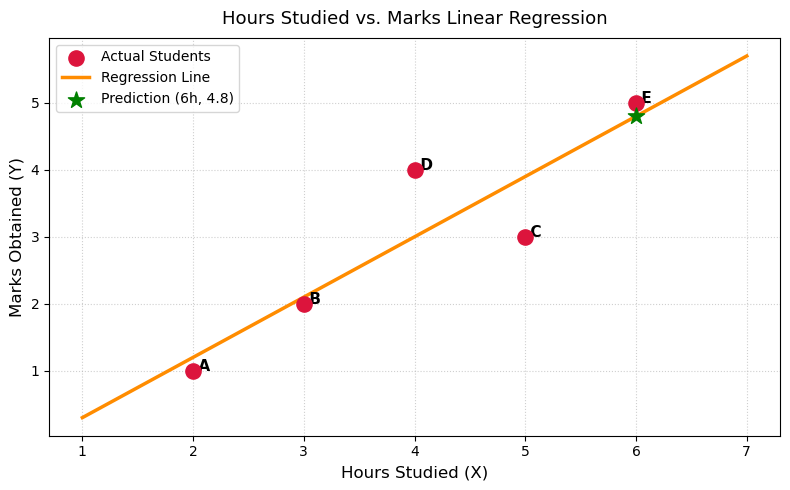

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

students = ['A', 'B', 'C', 'D', 'E']
hours = np.array([2, 3, 5, 4, 6]).reshape(-1, 1)
marks = np.array([1, 2, 3, 4, 5])

model = LinearRegression()
model.fit(hours, marks)

m = model.coef_[0]
c = model.intercept_
print(f"Regression Equation: Marks = {m:.1f} * Hours + ({c:.1f})")

predicted_marks = model.predict([[6]])[0]
print(f"Predicted marks for 6 hours of study: {predicted_marks:.1f}")
plt.figure(figsize=(8, 5))

plt.scatter(hours, marks, color='crimson', s=120, zorder=5, label='Actual Students')
for i, txt in enumerate(students):
    plt.annotate(f" {txt}", (hours[i][0], marks[i]), fontsize=11, fontweight='bold')

x_line = np.linspace(1, 7, 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='darkorange', linewidth=2.5, label='Regression Line')

plt.scatter([6], [predicted_marks], color='green', s=150, marker='*', zorder=6, label=f'Prediction (6h, {predicted_marks:.1f})')

plt.xlabel('Hours Studied (X)', fontsize=12)
plt.ylabel('Marks Obtained (Y)', fontsize=12)
plt.title('Hours Studied vs. Marks Linear Regression', fontsize=13, pad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()